In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

DF_PATH = Path("../data/Attack on Titan reviews.csv")
df = pd.read_csv(DF_PATH)

In [2]:
# check df
df.head()

,Rating,Title,Full Comment,Upvotes,Downvotes,Date
0,10,AOT: The Greatest Anime I've Ever Seen,Attack On Titan is officially over. And nothin...,755,50,"Nov 5, 2023"
1,10,Masterpiece. I've never witnessed this level o...,The moment you watch this audiovisual masterpi...,1.7K,136,"Jun 19, 2019"
2,10,Nearly perfect,"Before I started watching this show, I couldn'...",1.2K,107,"Dec 17, 2019"
3,10,My experience as a 42yrs. Old....,Growing up in the 80's 90's during the time of...,453,50,"Sep 2, 2021"
4,10,Well deserved to be alongside other greatest T...,I'm a more frequent American TV shows watcher ...,188,18,"Mar 28, 2023"


## Cleaning

In [3]:
# check size
df.size

12588

In [4]:
# check shape
df.shape

(2098, 6)

In [5]:
# drop "helpful ratings" rows
helpfulReviews = df[df.Rating == "Helpful"]
df.drop(axis=0, index=helpfulReviews.index, inplace=True)
df.head()

,Rating,Title,Full Comment,Upvotes,Downvotes,Date
0,10,AOT: The Greatest Anime I've Ever Seen,Attack On Titan is officially over. And nothin...,755,50,"Nov 5, 2023"
1,10,Masterpiece. I've never witnessed this level o...,The moment you watch this audiovisual masterpi...,1.7K,136,"Jun 19, 2019"
2,10,Nearly perfect,"Before I started watching this show, I couldn'...",1.2K,107,"Dec 17, 2019"
3,10,My experience as a 42yrs. Old....,Growing up in the 80's 90's during the time of...,453,50,"Sep 2, 2021"
4,10,Well deserved to be alongside other greatest T...,I'm a more frequent American TV shows watcher ...,188,18,"Mar 28, 2023"


In [6]:
# check data types
df.dtypes

Rating          str
Title           str
Full Comment    str
Upvotes         str
Downvotes       str
Date            str
dtype: object

In [7]:
# replace Upvotes K with 00
df.Upvotes = df.Upvotes.str.replace(".", "")
df.Upvotes = df.Upvotes.str.replace("K", "00")
df.Upvotes

0        755
1       1700
2       1200
3        453
4        188
        ... 
2093       3
2094       3
2095       3
2096       3
2097       3
Name: Upvotes, Length: 2053, dtype: str

In [8]:
df.Date = df.Date.str.replace(",", "")

# creating 3 new columns: month, day, year
df[["Month", "Day", "Year"]] = df["Date"].str.split(" ", expand=True)
df.drop("Date", axis=1, inplace=True)

In [9]:
# change data type
df.Year = df.Year.astype("int64")
df.Day = df.Day.astype("int64")

In [10]:
df.Upvotes = df.Upvotes.astype("int64")
df.Downvotes = df.Downvotes.str.replace(".", "")
df.Downvotes = df.Downvotes.str.replace("K", "00")
df.Downvotes = df.Downvotes.astype("int64")

df.dtypes

Rating            str
Title             str
Full Comment      str
Upvotes         int64
Downvotes       int64
Month             str
Day             int64
Year            int64
dtype: object

In [11]:
# create comment word count
df["Comment Word Count"] = df["Full Comment"].str.split().str.len()

## EXPLORATORY DATA ANALYSIS

### Upvotes vs Downvotes + Upvotes Ratio

In [12]:
descrTable = df.describe(include=["int64"], exclude="object").round(2)
descrTable

,Upvotes,Downvotes,Day,Year,Comment Word Count
count,2053.00,2053.00,2053.00,2053.00,2053.00
mean,14.93,9.27,15.49,2021.11,85.34
std,64.08,45.24,8.89,2.19,109.93
min,0.00,0.00,1.00,2013.00,1.00
25%,4.00,0.00,8.00,2021.00,16.00
50%,6.00,1.00,15.00,2021.00,46.00
75%,10.00,3.00,24.00,2022.00,118.00
max,1700.00,1100.00,31.00,2025.00,1161.00


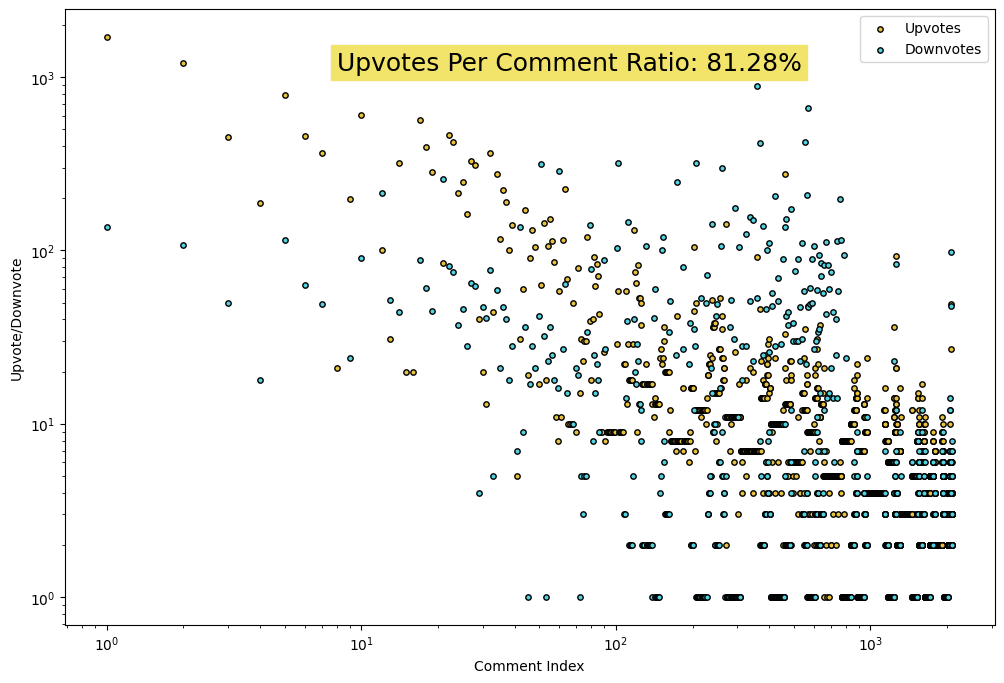

In [13]:
# upvotes vs downvotes + upvotes ratio
upvotes = df.Upvotes.values
downvotes = df.Downvotes.values
upvotesPerCommentRatio = np.mean(upvotes / (upvotes + downvotes) * 100)

plt.figure(figsize=(12, 8))

plt.scatter(df.index, upvotes, edgecolor="black", color="#E8C13F",
            label="Upvotes", s=15)
plt.scatter(df.index, downvotes, edgecolor="black", color="#53D2E0",
            label="Downvotes", s=15)
plt.legend(loc="upper right")
plt.xlabel("Comment Index", loc="center")
plt.ylabel("Upvote/Downvote", loc="center")
plt.text(x=8, y=1100, s=f"Upvotes Per Comment Ratio: {np.round(upvotesPerCommentRatio, decimals=2)}%",
         fontsize=18, color="black", backgroundcolor="#F2E46B")
plt.xscale("log")
plt.yscale("log")

### Time trends: Plotting upvotes over time.


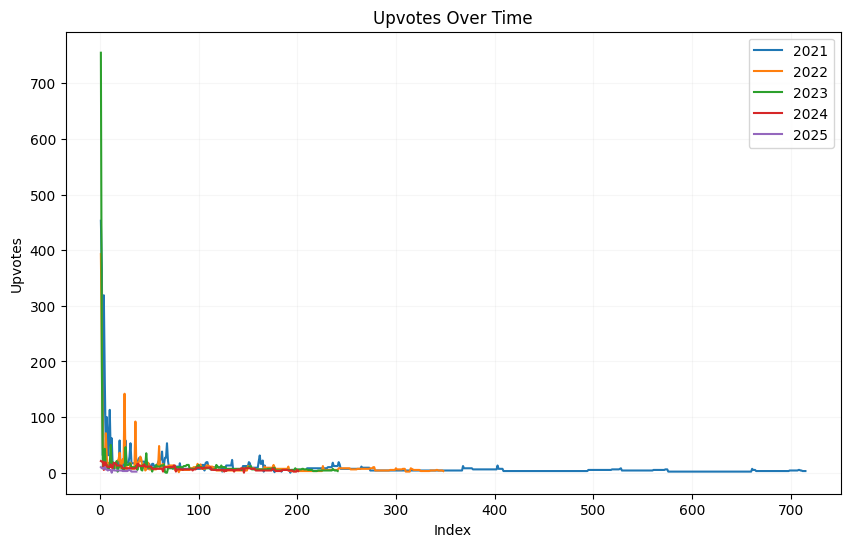

In [14]:
ratings2025 = df[df.Year == 2025]["Upvotes"].values
ratings2024 = df[df.Year == 2024]["Upvotes"].values
ratings2023 = df[df.Year == 2023]["Upvotes"].values
ratings2022 = df[df.Year == 2022]["Upvotes"].values
ratings2021 = df[df.Year == 2021]["Upvotes"].values
legendLabels = [2021, 2022, 2023, 2024, 2025]

def createXValues(ratings):
  return np.arange(1, len(ratings) + 1)

plt.figure(figsize=(10, 6))

plt.plot(createXValues(ratings2021), ratings2021, linewidth=1.5, aa=True)
plt.plot(createXValues(ratings2022), ratings2022, linewidth=1.5, aa=True)
plt.plot(createXValues(ratings2023), ratings2023, linewidth=1.5, aa=True)
plt.plot(createXValues(ratings2024), ratings2024, linewidth=1.5, aa=True)
plt.plot(createXValues(ratings2025), ratings2025, linewidth=1.5, aa=True)
plt.title("Upvotes Over Time")
plt.grid(alpha=0.1)
plt.xlabel("Index")
plt.ylabel("Upvotes")
plt.legend(legendLabels)

### Review Length Analysis: see if longer reviews get more upvotes. Then plot distribution of short vs. long reviews.

Text(0.5, 0.98, "Longer Reviews Don't Mean Higher Upvotes")

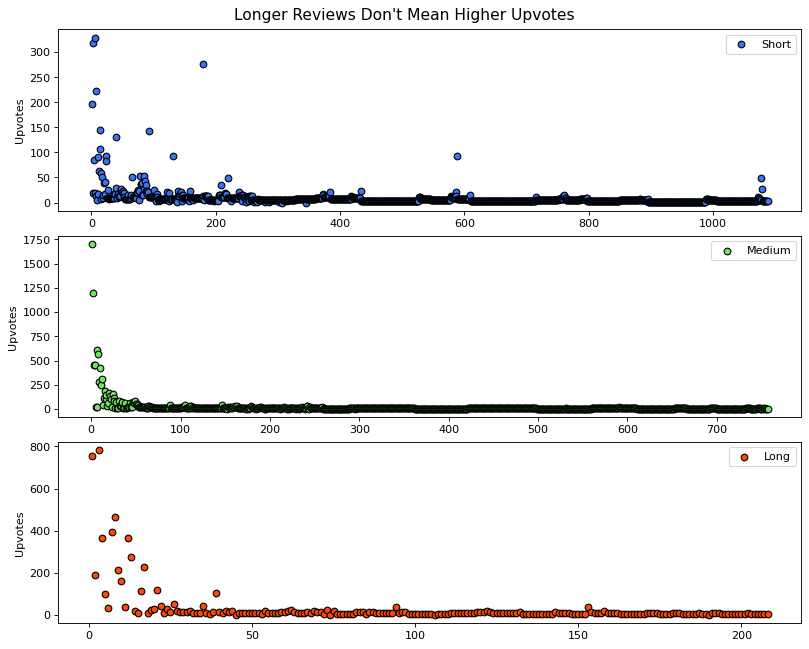

In [15]:
df["Review Length"] = df['Full Comment'].str.split(" ").str.len()
# min, max and mean
minReviewLength = min(df['Review Length'])
maxReviewLength = max(df['Review Length'])
meanReviewLength = np.mean(df['Review Length'])

# creating a categorical columns
bins = [0, 50, 200, 1200]
labels = ['Short', 'Medium', 'Long']

df['Review Length Category'] = pd.cut(df['Review Length'], bins=bins,
                                      labels=labels)
df['Review Length Category'] = df['Review Length Category'].astype('category')

# avg. Upvotes per category
avgUpvotesShort = df[df['Review Length Category'] == "Short"]['Upvotes'].mean()
avgUpvotesMedium = df.loc[df['Review Length Category'] == "Medium"]['Upvotes'].mean()
avgUpvotesLong = df.loc[df['Review Length Category'] == "Long"]['Upvotes'].mean()

# plotting to see results
def calcXValues(series: pd.Series):
  return np.arange(1, len(series) + 1)

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 8), dpi=80,
                         constrained_layout=True)

axes[0].scatter(calcXValues(df[df['Review Length Category'] == "Short"]['Upvotes']),
                df[df['Review Length Category'] == "Short"]['Upvotes'].values, label="Short",
                color="#3874F5", ec="black")
axes[0].set_ylabel("Upvotes")
axes[0].legend()

axes[1].scatter(calcXValues(df[df['Review Length Category'] == "Medium"]['Upvotes']),
                df[df['Review Length Category'] == "Medium"]['Upvotes'].values, label="Medium",
                color="#70E660", ec="black")
axes[1].set_ylabel("Upvotes")
axes[1].legend()

axes[2].scatter(calcXValues(df[df['Review Length Category'] == "Long"]['Upvotes']),
                df[df['Review Length Category'] == "Long"]['Upvotes'].values, label="Long",
                color="#FF4808", ec="black")
axes[2].set_ylabel("Upvotes")
axes[2].legend()

plt.suptitle("Longer Reviews Don't Mean Higher Upvotes", fontsize=14)

### Upvotes By Year (2013-2024)

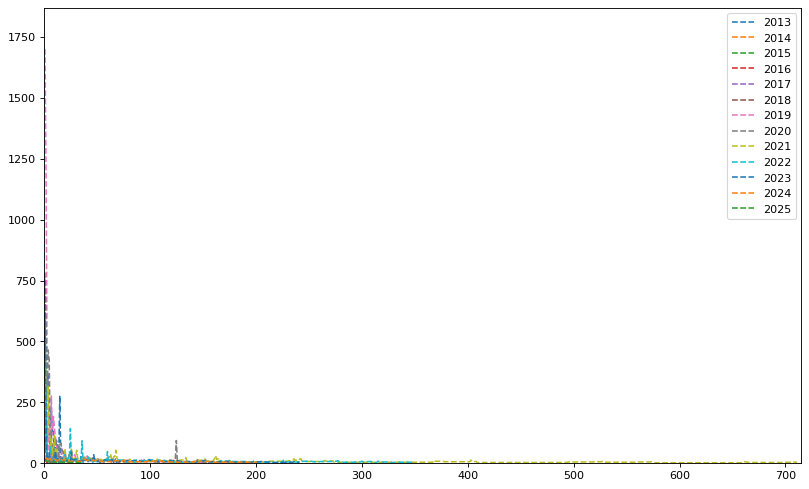

In [16]:
from matplotlib.animation import FuncAnimation
from matplotlib import rc
rc('animation', html='jshtml')

years = sorted(df.Year.unique())
allUpvotes = df["Upvotes"].values

def upvotesPerYear(year: int):
  return df[df.Year == year]["Upvotes"].values

maxLength = max(len(upvotesPerYear(year)) for year in years)


fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 6),
                         constrained_layout=True, dpi=80)

# creating the lines
lines = []
for year in years:
  line, = axes.plot([], [], label=str(year), linestyle="--", linewidth=1.4)
  lines.append(line)

axes.legend(loc="best")
axes.set_xlim(0, maxLength)
axes.set_ylim(0, max(allUpvotes) * 1.1)

def init():
  for line in lines:
    line.set_data([], [])

  return lines

def animate(frame):
  for line, year in zip(lines, years):
    y = upvotesPerYear(year)
    x = np.arange(1, len(y) + 1)
    line.set_data(x[:frame], y[:frame])

  return lines


anim = FuncAnimation(
    fig=fig,
    func=animate,
    frames=range(1, maxLength + 1, 5),
    init_func=init,
    interval=150,
    blit=True
)

anim

### Most Frequent Words

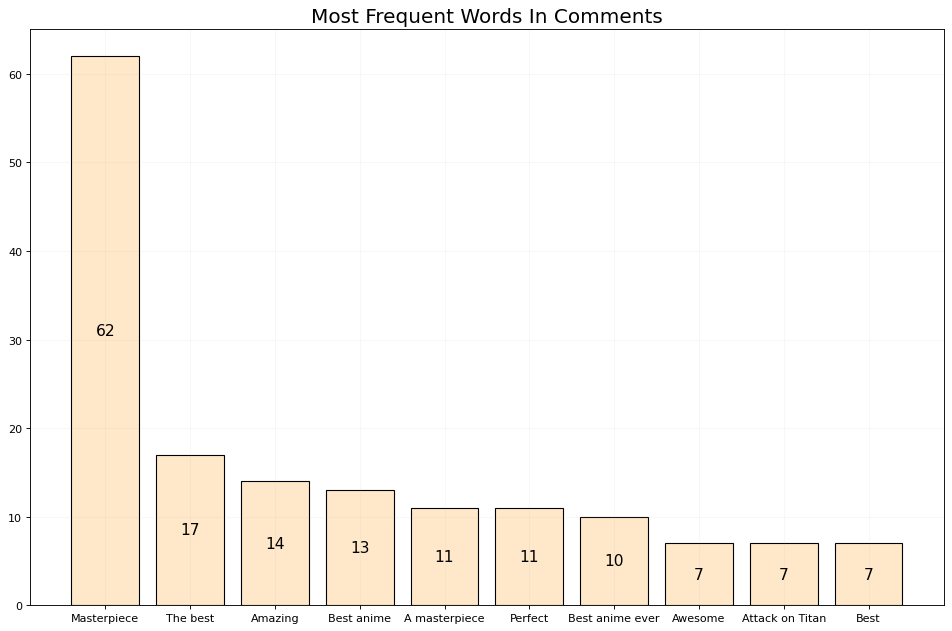

In [17]:
mostFrequent10Words = df.Title.value_counts(ascending=False, dropna=True).nlargest(10)
mostFrequent10WordsIndex = mostFrequent10Words.index
mostFrequent10WordsValues = mostFrequent10Words.values

plt.figure(figsize=(12, 8), dpi=80)

barChart = plt.bar(mostFrequent10WordsIndex, mostFrequent10WordsValues, align="center",
        edgecolor="black", color="#ffe8c9")
plt.bar_label(barChart, label_type="center", fontsize=14)
plt.title("Most Frequent Words In Comments", fontsize=18)
plt.grid(alpha=0.1)
plt.tight_layout()

### Group by Month to see if more reviews come in certain months


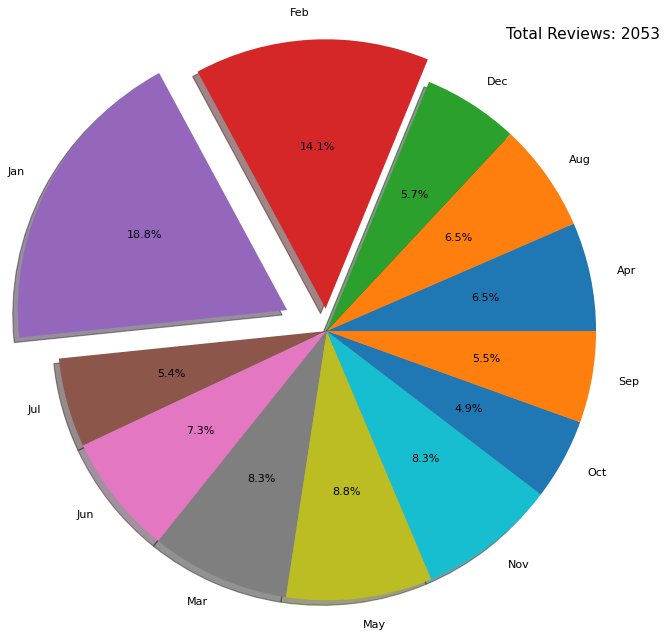

In [18]:
monthGroups = df.groupby("Month")["Title"].count()
totalValues = df["Title"].count()
explode = (0, 0, 0, 0.1, 0.2, 0, 0, 0, 0, 0, 0, 0)

plt.figure(figsize=(12, 8), dpi=80)

plt.pie(monthGroups.values, labels=monthGroups.index, autopct="%1.1f%%",
        shadow=True, explode=explode, radius=1.2)
plt.text(x=0.8, y=1.3, s=f"Total Reviews: {totalValues}", fontsize=14)
plt.tight_layout()

In [19]:
# ratings proportion
df.value_counts(dropna=True, normalize=True, subset=["Rating"])

Rating
10        0.877253
9         0.048222
7         0.021432
6         0.012177
5         0.010716
8         0.007306
4         0.006332
2         0.005845
3         0.005358
1         0.005358
Name: proportion, dtype: float64

### Seasonality: Group by Month and Year to see Avg. Upvotes

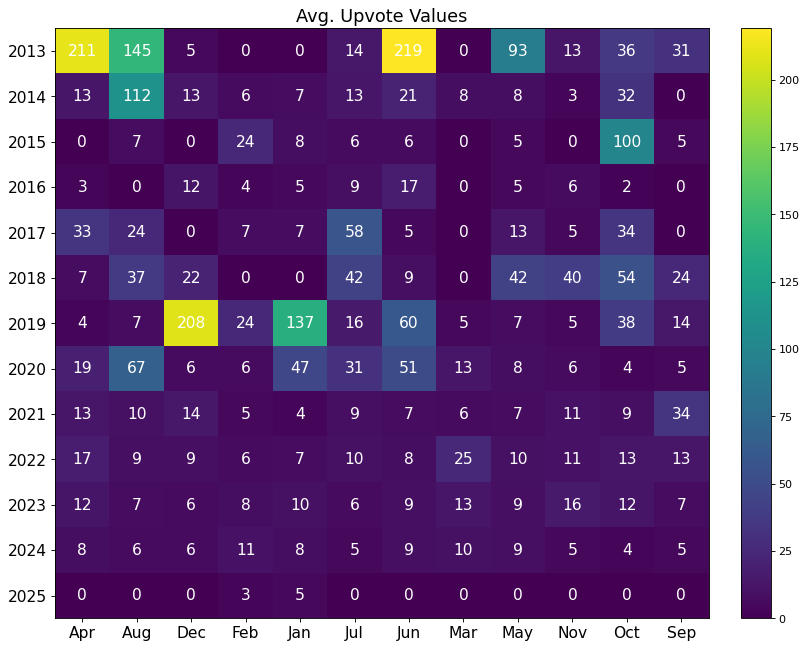

In [20]:
pivotT = df.pivot_table(index="Year", columns="Month", values="Upvotes",
                                aggfunc="mean")
pivotT = pivotT.replace(np.nan, 0)
pivotT = pivotT.astype("int32")

# data
months = np.array(pivotT.columns)
years = np.arange(2013, 2025 + 1)
pivotValues = np.array(pivotT.values)

fig, ax = plt.subplots(figsize=(10, 8), dpi=80, nrows=1, ncols=1,
                       constrained_layout=True)

heatmap = ax.imshow(pivotValues, aspect="auto", cmap="viridis")
cbar = ax.figure.colorbar(heatmap)
ax.set_xticks(range(len(months)), months, fontsize=14)
ax.set_yticks(range(len(years)), years, fontsize=14)
ax.set_title("Avg. Upvote Values", fontsize=16)

for i in range(len(years)):
  for j in range(len(months)):
    text = ax.text(j, i, pivotValues[i, j], ha="center", va="center",
                   color="white", fontsize=14)


### Cumulative Popularity: Cumulative sum of upvotes across time → shows how fandom grew


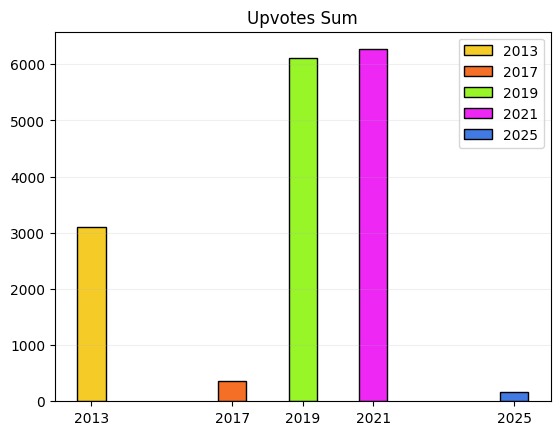

In [21]:
upvotesSum2013 = df[df.Year == 2013]["Upvotes"].sum()
upvotesSum2017 = df[df.Year == 2017]["Upvotes"].sum()
upvotesSum2019 = df[df.Year == 2019]["Upvotes"].sum()
upvotesSum2021 = df[df.Year == 2021]["Upvotes"].sum()
upvotesSum2025 = df[df.Year == 2025]["Upvotes"].sum()

xLabelsYears = [2013, 2017, 2019, 2021, 2025]
yUpvotesSum = [upvotesSum2013, upvotesSum2017, upvotesSum2019, upvotesSum2021,
               upvotesSum2025]
colors = ["#F5CC27", "#F56F27", "#98F527", "#EE27F5", "#427AE3"]

plt.bar(xLabelsYears, yUpvotesSum, color=colors, edgecolor="black",
        align="center", label=xLabelsYears)
plt.title("Upvotes Sum")
plt.xticks(xLabelsYears)
plt.legend(loc="upper right")
plt.grid(axis="y", alpha=0.2)

### Upvotes vs. Downvotes ratio evolution over time


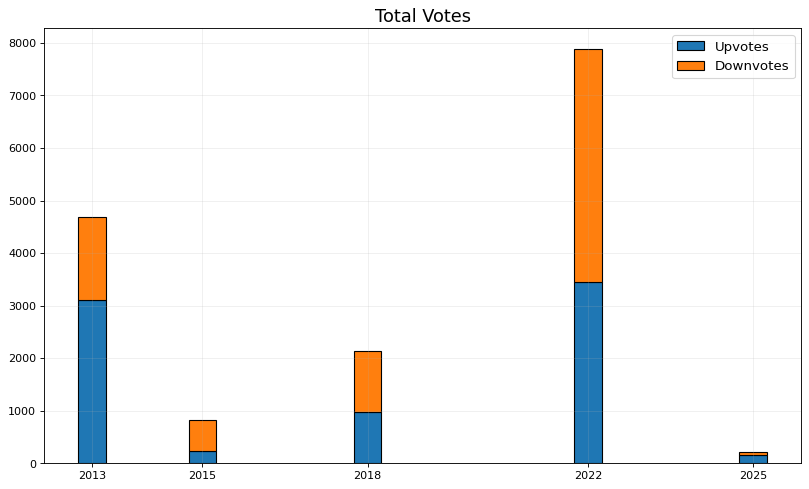

In [22]:
years = [2013, 2015, 2018, 2022, 2025]
voteTypes = ["Upvotes", "Downvotes"]
colors = ["#bd4275", "#6495ed"]

def getUpvotesPerYear(year):
  return df.groupby("Year").get_group(year)["Upvotes"].sum()

def getDownvotesPerYear(year):
  return df.groupby("Year").get_group(year)["Downvotes"].sum()

votesData = {
    "Upvotes": [getUpvotesPerYear(2013), getUpvotesPerYear(2015), getUpvotesPerYear(2018),
                getUpvotesPerYear(2022), getUpvotesPerYear(2025)],
    "Downvotes": [getDownvotesPerYear(2013), getDownvotesPerYear(2015), getDownvotesPerYear(2018),
                  getDownvotesPerYear(2022), getDownvotesPerYear(2025)],
}

# plot
width = 0.5
bottom = np.zeros(5)

fig, ax = plt.subplots(figsize=(10, 6), dpi=80, nrows=1, ncols=1,
                       constrained_layout=True)

for text, data in votesData.items():
  ax.bar(years, data, width, label=text, bottom=bottom,
         edgecolor="black")
  bottom += data

ax.set_title("Total Votes", fontsize=16, color="black")
ax.set_xticks(years)
ax.legend(loc="upper right", fontsize=12)
ax.grid(alpha=0.2)

## Machine Learning

### Multiple Linear Regr. Model using word count and year to predict upvotes


In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

X = df[["Year", "Comment Word Count"]].values
y = df["Upvotes"].values

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# model
regr = LinearRegression()
regr.fit(x_train_scaled, y_train)

y_pred = regr.predict(x_test_scaled)

# metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
modelCoeff = regr.coef_
modelIntercept = regr.intercept_

print(f"MAE: {mae}")
print(f"R2 score: {r2}")
print(f"Model coeff.: {modelCoeff}")
print(f"Model intercept: {modelIntercept}")

MAE: 13.833855312111227
R2 score: 0.09520600848860816
Model coeff.: [-8.60090741 11.66456973]
Model intercept: 15.42021924482367


### K-Means Clustering

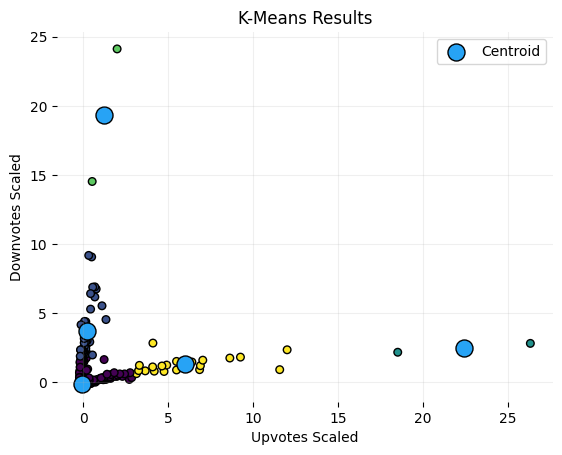

In [24]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

xKMeans = df[['Upvotes', 'Downvotes']].values
sc = StandardScaler()
xKMeans = sc.fit_transform(xKMeans)

# elbow method to find optimal k --> 5
inertias = []

for i in range(1, 11):
  kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
  kmeans.fit(xKMeans)
  inertias.append(kmeans.inertia_)

# plotting
"""
plt.plot(range(1, 11), inertias, marker='o')
plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.show()
"""

kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
kmeans.fit(xKMeans)
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

plt.scatter(xKMeans[:, 0], xKMeans[:, 1], ec="black", c=labels, s=30)
# centroids
plt.scatter(centroids[:, 0], centroids[:, 1], ec="black", s=150,
            color='#27A3F5', label="Centroid")
plt.xlabel("Upvotes Scaled")
plt.ylabel("Downvotes Scaled")
plt.title("K-Means Results")
plt.box(False)
plt.legend(loc='best')
plt.grid(alpha=0.2)

# Conclusions


## Exploratory Data Analysis

1.	The average percentage of upvotes per comment is 81.28%, indicating a strong upvote count vs. downvote count. 
2.	From 2021 to 2025 AOT comment upvotes largely increased at the beginning of the analysis and then reduced over time. This doesn’t necessarily mean upvotes decreased over time because the data isn’t sorted.
3.	Longer reviews don’t necessarily get higher upvotes. The data suggests some medium-length reviews get higher upvotes compared to longer ones. 
4.	The most frequent words in comments are “Masterpiece”, “The best” and “Amazing”. This implies anime fans like the series a lot and confirms the point that users gave the anime a rating of 10 88% of the time.
5.	Among a total of 2053 reviews, most reviews come in January (18.8% of that data), followed by February (14.1%) and May (8.8%).
6.	When considering 2013, 2017, 2019, 2021 and 2025, the most upvotes came in 2021, followed by 2019 and 2013. 

## Machine Learning

1.	Using comment word count and years to predict upvotes using a multiple linear regression model isn’t useful. The low r² score of 0.1 demonstrates the model doesn’t explain much variance. It doesn’t capture the pattern.
Furthermore, the mean absolute error of 13.9 shows the model, on average, gets an upvote prediction wrong by 13.9. For an upvote it is high enough. 
2.	K-Means Clustering suggests creating 5 possible comment groups:
-	Cluster 1: it is at the bottom left and it represents most of the comments, which have small upvotes and downvotes (low engagement).
-	Clusters 2 and 3: these are close to cluster 1 and represent comments that receive higher/lower upvotes/downvotes. 
-	Clusters 4 and 5: these are far away from the other clusters and likely represent outliers that receive a high upvote/downvote count.